Group 15 - DA6701 Assignment 1

Team Members:

CE22B085 - Krima Patel

CE22B089 - Pragati L

CE22B099 - Samarth K J

CE22B101 - Samyam Rishika

CE22B103 - Sarvesh Shanbhag

In [6]:
import pandas as pd
import glob
import os

# Folder where your 6 CSV files are stored
folder_path = r"C:\Users\HP\Downloads\ticker_returns (2)\ticker_returns"   # <-- change this

# Get all CSV files
files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []

for file in files:
    # Read file
    df = pd.read_csv(file, parse_dates=["Date"])
    
    # Extract only Date and Predicted_Return
    df = df[["Date", "Predicted_Return"]]
    
    # Rename column to stock name (file name without .csv)
    stock_name = os.path.basename(file).replace(".csv", "")
    df.rename(columns={"Predicted_Return": stock_name}, inplace=True)
    
    # Set Date as index
    df.set_index("Date", inplace=True)
    
    dfs.append(df)

# Merge all files column-wise on Date
merged_df = pd.concat(dfs, axis=1)

# Sort by date
merged_df.sort_index(inplace=True)

# Optional: forward fill missing values
merged_df.fillna(method="ffill", inplace=True)

# Save final merged file
merged_df.to_csv("Merged_Predicted_Returns.csv")

print("Merged file saved successfully!")
print(merged_df.head())

Merged file saved successfully!
            AIRTEL_returns  HDFC_returns  HUL_returns  INFY_returns  \
Date                                                                  
2025-10-01        0.001664      0.001960     0.001860      0.001694   
2025-10-03        0.001213      0.000799    -0.007488      0.001085   
2025-10-06        0.001198      0.001148    -0.000951      0.000833   
2025-10-07        0.000254      0.000598    -0.001495      0.000295   
2025-10-08        0.000009     -0.000183    -0.000507     -0.000635   

            MANDM_returns  RELIANCE_returns  
Date                                         
2025-10-01       0.001811          0.001243  
2025-10-03       0.000868          0.000238  
2025-10-06       0.001646          0.000751  
2025-10-07      -0.000077          0.000123  
2025-10-08      -0.000660         -0.000024  


C:\Users\HP\AppData\Local\Temp\ipykernel_23392\2283127368.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method="ffill", inplace=True)


In [7]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
rf=0.065 # Risk-free Rate = 6.5%
df = pd.read_csv(r"C:\Users\HP\Downloads\Group_15\Merged_Predicted_Returns.csv",
                 parse_dates=['Date'], index_col='Date')

In [4]:
df=df/100 # Converting Daily returns from Percentage to Decimal Values
df.shape

(60, 6)

In [10]:
df

,AIRTEL_returns,HDFC_returns,HUL_returns,INFY_returns,MANDM_returns,RELIANCE_returns
Date,,,,,,
2025-10-01,0.001664,0.001960,0.001860,0.001694,0.001811,1.242542e-03
2025-10-03,0.001213,0.000799,-0.007488,0.001085,0.000868,2.376213e-04
2025-10-06,0.001198,0.001148,-0.000951,0.000833,0.001646,7.506491e-04
2025-10-07,0.000254,0.000598,-0.001495,0.000295,-0.000077,1.229716e-04
2025-10-08,0.000009,-0.000183,-0.000507,-0.000635,-0.000660,-2.440858e-05
2025-10-09,0.000855,0.000543,0.000222,0.000496,0.000436,-9.524744e-05
2025-10-10,0.001669,0.001859,0.001615,0.001775,0.001456,9.052778e-04
2025-10-13,0.002136,0.000968,0.002550,0.001850,0.001807,5.336825e-04
2025-10-14,0.004304,0.002049,-0.001004,0.001231,0.003320,1.603276e-03


In [11]:
corr=df.corr() # calculating Correlation Matrix
corr

,AIRTEL_returns,HDFC_returns,HUL_returns,INFY_returns,MANDM_returns,RELIANCE_returns
AIRTEL_returns,1.000000,0.916522,0.810089,0.863601,0.900448,0.879755
HDFC_returns,0.916522,1.000000,0.821358,0.964819,0.960753,0.954088
HUL_returns,0.810089,0.821358,1.000000,0.815684,0.816376,0.803770
INFY_returns,0.863601,0.964819,0.815684,1.000000,0.955858,0.935380
MANDM_returns,0.900448,0.960753,0.816376,0.955858,1.000000,0.944955
RELIANCE_returns,0.879755,0.954088,0.803770,0.935380,0.944955,1.000000


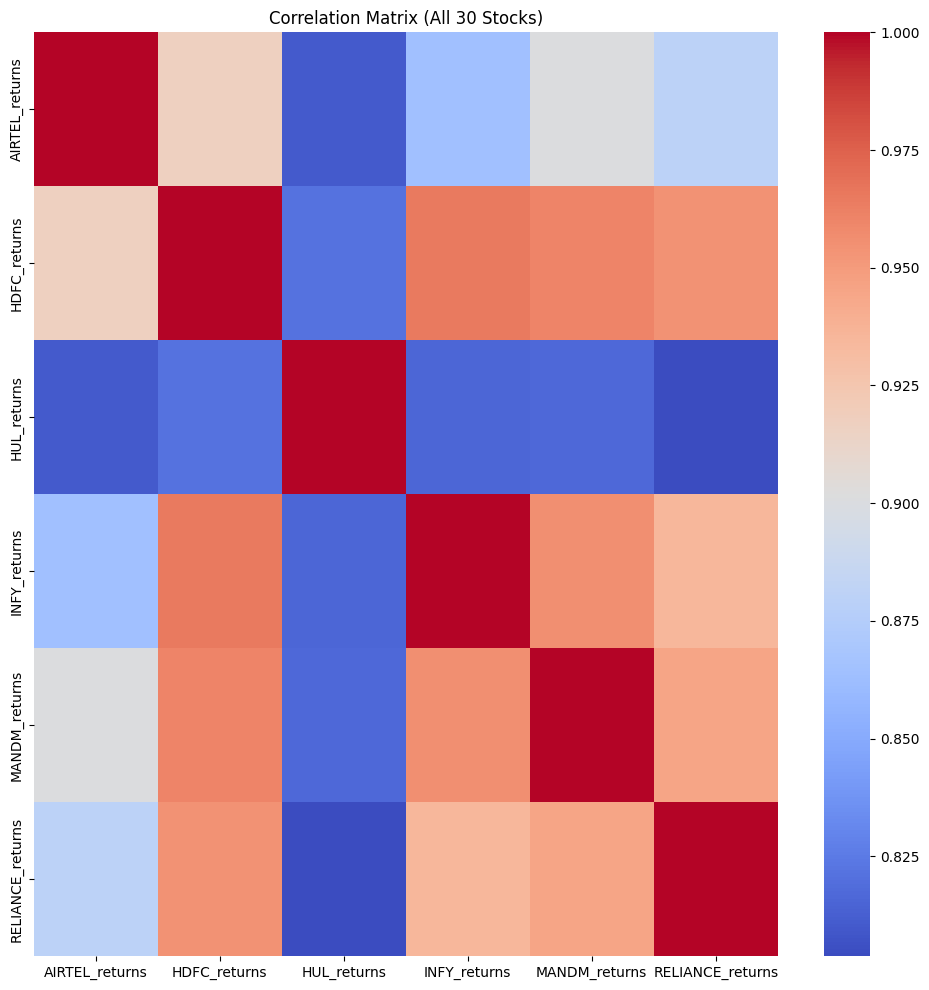

In [12]:
# Plotting Correlation Heatmap
plt.figure(figsize=(12,12))
sns.heatmap(corr,cmap='coolwarm')
plt.title('Correlation Matrix (All 30 Stocks)')
plt.show()

In [13]:
corr.min().min(), corr.min().max()

(0.8037697260680186, 0.8213581359235034)

Selected Stocks: ['HUL_returns', 'RELIANCE_returns', 'AIRTEL_returns', 'INFY_returns', 'MANDM_returns', 'HDFC_returns']


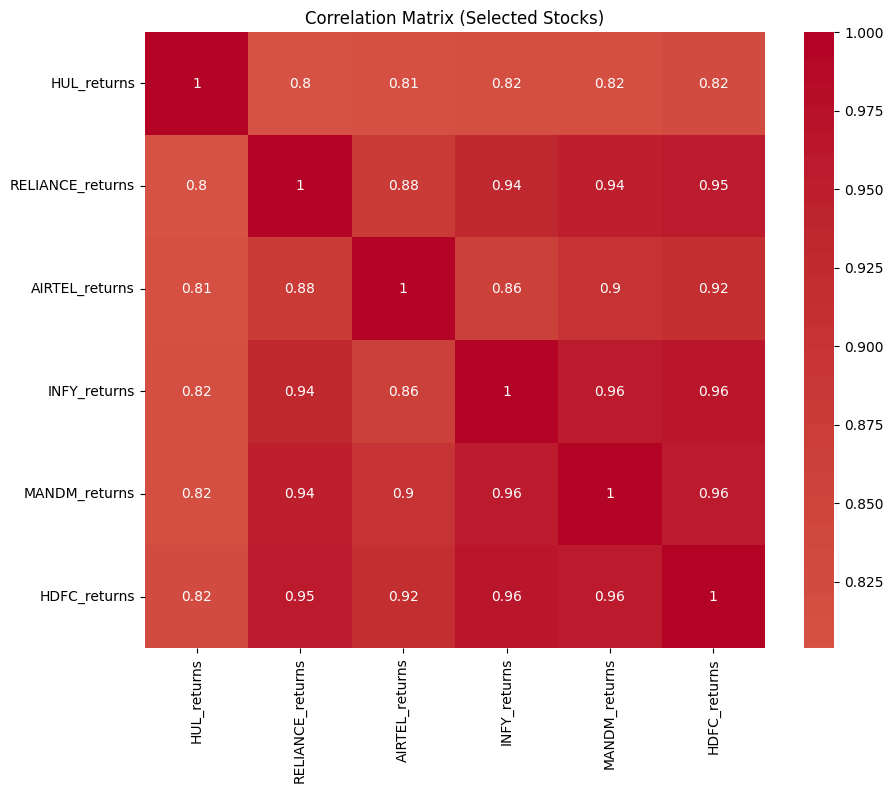

In [14]:
# Algorithmically finding the 10 least correlated stocks.
# Step 1: Select the stock with the least average correlation
# Step 2: From the rest of the stocks, select stocks that have the least average correlation with the stocks that have already been selected. Repeat this 9 times.
def low_corr_stocks(df_returns, num_stocks=10):
    corr_matrix = df_returns.corr()
    avg_corrs = corr_matrix.mean()
    selected = [avg_corrs.idxmin()]

    for _ in range(num_stocks - 1):
        candidates = [s for s in df_returns.columns if s not in selected]
        best_candidate = None
        min_avg_corr_with_selected = float('inf')
        for cand in candidates:
            avg_corr = corr_matrix.loc[cand, selected].mean()
            if avg_corr < min_avg_corr_with_selected:
                min_avg_corr_with_selected = avg_corr
                best_candidate = cand
        selected.append(best_candidate)
    return selected

portfolio = low_corr_stocks(df, num_stocks=6)

print(f"Selected Stocks: {portfolio}")

plt.figure(figsize=(10, 8))
sns.heatmap(df[portfolio].corr(), cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Matrix (Selected Stocks)")
plt.show()



In [15]:
df_selected = df[portfolio]
n_assets = len(portfolio) #10 assets
n_portfolios=20000 #20000 iterations for Monte-Carlo Simulation

In [16]:
weights=np.zeros((n_portfolios,n_assets)) # weights (20000,10)
returns=np.zeros(n_portfolios) # returns (20000,1)
risk=np.zeros(n_portfolios) # risk = volatility = variance (20000,1)
sharpe=np.zeros(n_portfolios) # sharpe ratio (20000,1)
mean_daily_returns=df_selected.mean() # mean daily returns of the selected stocks
cov_matrix=df_selected.cov() # covariance matrix of the selected stocks

In [17]:
# Monte-Carlo Simulation
for i in range(n_portfolios):
  w=np.random.random(n_assets) # w>=0
  w=w/np.sum(w) # summation of weights=1
  weights[i,:]=w
  returns[i]=np.sum(mean_daily_returns*w)*252 # annualized returns
  risk[i]=np.sqrt(np.dot(w.T,np.dot(cov_matrix,w)))*np.sqrt(252) # annualized risk
  sharpe[i]=(returns[i]-rf)/risk[i] # sharpe ratio

In [18]:
# Maximum Sharpe Ratio Portfolio Statistics
max_sharpe_idx=sharpe.argmax()
max_sharpe_return=returns[max_sharpe_idx]
max_sharpe_risk=risk[max_sharpe_idx]
max_sharpe=sharpe[max_sharpe_idx]
max_sharpe_weights=weights[max_sharpe_idx]

In [19]:
max_sharpe_idx, max_sharpe_return,max_sharpe_risk,max_sharpe,max_sharpe_weights

(18059,
 0.1750633325842368,
 0.03404215653005158,
 3.2331480670760557,
 array([0.01079289, 0.03259263, 0.61819859, 0.03647689, 0.20589591,
        0.0960431 ]))

In [20]:
# Global Minimum Variance Portfolio Statistics
min_var_idx=risk.argmin()
min_var_return=returns[min_var_idx]
min_var_risk=risk[min_var_idx]
min_var_sharpe=sharpe[min_var_idx]
min_var_weights=weights[min_var_idx]

In [21]:
min_var_idx, min_var_return,min_var_risk,min_var_sharpe,min_var_weights

(589,
 0.09602870162424725,
 0.033477139149703,
 0.9268624025933984,
 array([0.2934644 , 0.02416031, 0.27295345, 0.00115925, 0.15023444,
        0.25802816]))

In [22]:
df_results=pd.DataFrame({
    'Stock':portfolio,
    'Maximum Sharpe Weights': max_sharpe_weights,
    'Global Minimum Variance (GMV) Weights': min_var_weights
})

In [23]:
df_results['Maximum Sharpe Weights']=df_results['Maximum Sharpe Weights'].apply(lambda x: f"{x:.2%}")
df_results['Global Minimum Variance (GMV) Weights']=df_results['Global Minimum Variance (GMV) Weights'].apply(lambda x: f"{x:.2%}")

In [24]:
print(df_results)
print(f'Max Sharpe Ratio: {max_sharpe:.4f} | Max Sharpe Return: {max_sharpe_return:.4f} | Max Sharpe Risk: {max_sharpe_risk:.4f} ')
print(f'GMV Sharpe Ratio: {min_var_sharpe:.4f} | GMV Return: {min_var_return:.4f} | GMV Risk: {min_var_risk:.4f} ')


              Stock Maximum Sharpe Weights  \
0       HUL_returns                  1.08%   
1  RELIANCE_returns                  3.26%   
2    AIRTEL_returns                 61.82%   
3      INFY_returns                  3.65%   
4     MANDM_returns                 20.59%   
5      HDFC_returns                  9.60%   

  Global Minimum Variance (GMV) Weights  
0                                29.35%  
1                                 2.42%  
2                                27.30%  
3                                 0.12%  
4                                15.02%  
5                                25.80%  
Max Sharpe Ratio: 3.2331 | Max Sharpe Return: 0.1751 | Max Sharpe Risk: 0.0340 
GMV Sharpe Ratio: 0.9269 | GMV Return: 0.0960 | GMV Risk: 0.0335 


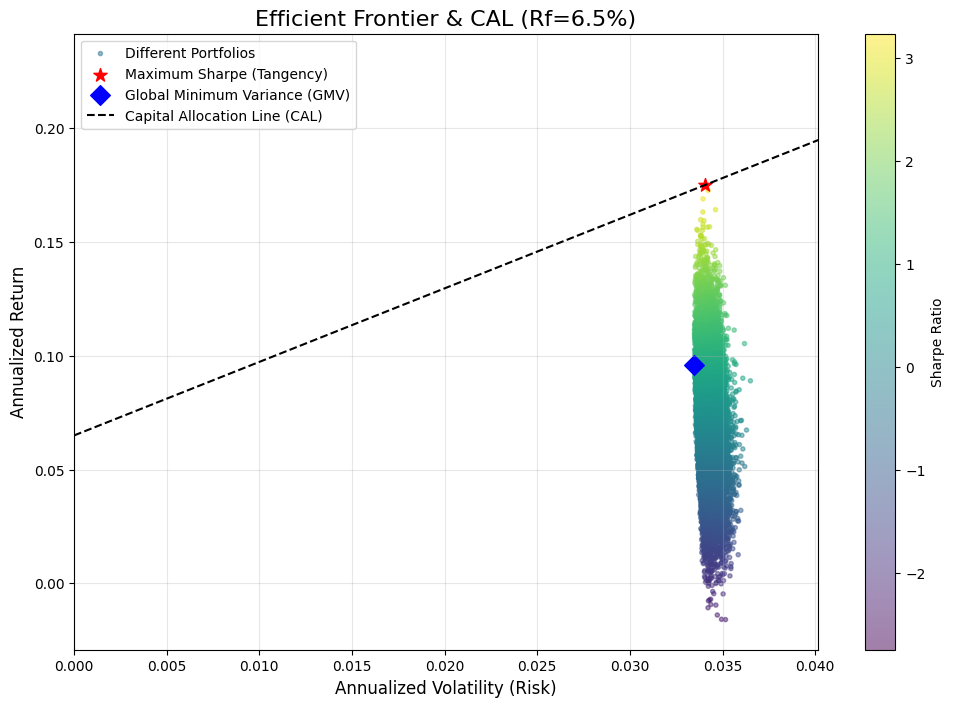

In [25]:
plt.figure(figsize=(12, 8))

# 1. Plot the 10,000 Random Portfolios
plt.scatter(risk, returns, c=sharpe, cmap='viridis', marker='.', alpha=0.5, label='Different Portfolios')
plt.colorbar(label='Sharpe Ratio')

# 2. Plot the Important Points
plt.scatter(max_sharpe_risk, max_sharpe_return, c='red', s=100, marker='*', label='Maximum Sharpe (Tangency)')
plt.scatter(min_var_risk, min_var_return, c='blue', s=100, marker='D', label='Global Minimum Variance (GMV)')

# 3. Plot the Capital Allocation Line (CAL)
# Line from Risk-Free Rate (0 risk) to Tangency Point
cal_x = [0, max_sharpe_risk, max_sharpe_risk * 1.5] # Extend line slightly past tangency
cal_y = [rf, max_sharpe_return, rf + (max_sharpe_return - rf) * 1.5]
plt.plot(cal_x, cal_y, 'k--', linewidth=1.5, label='Capital Allocation Line (CAL)')

# Formatting
plt.title(f'Efficient Frontier & CAL (Rf={rf:.1%})', fontsize=16)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(risk)*1.1) # Start x-axis at 0 to show the CAL origin
plt.ylim(min(returns)*0.9, max(cal_y)*1.05)

plt.show()

Total Cumulative Return: 4.24%


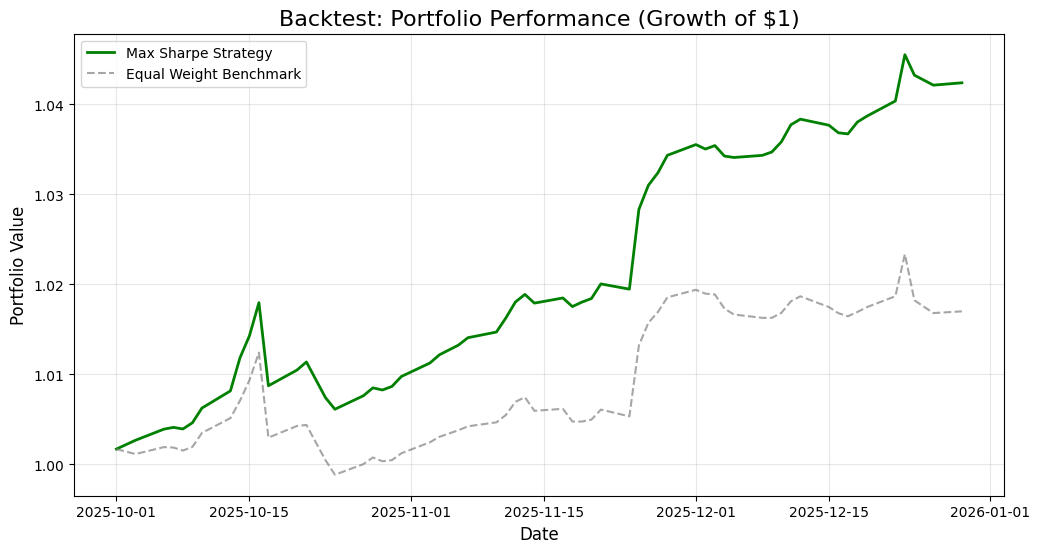

In [26]:
# Calculating Daily Portfolio Returns
portfolio_daily_returns = (df[portfolio] * max_sharpe_weights).sum(axis=1) # Multiply daily stock returns by optimized weights

# Calculating Cumulative Returns (Growth of $1)
# Formula: (1 + r1) * (1 + r2) * ...
cumulative_returns = (1 + portfolio_daily_returns).cumprod()

# Using an "Equal Weight" portfolio as a benchmark to beat
equal_weights = np.ones(len(portfolio)) / len(portfolio)
benchmark_daily_returns = (df[portfolio] * equal_weights).sum(axis=1)
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

# Plotting the Results
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns.index, cumulative_returns, label='Max Sharpe Strategy', color='green', linewidth=2)
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label='Equal Weight Benchmark', color='grey', linestyle='--', alpha=0.7)

plt.title('Backtest: Portfolio Performance (Growth of $1)', fontsize=16)
plt.ylabel('Portfolio Value', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Print Final Return
total_return = cumulative_returns.iloc[-1] - 1
print(f"Total Cumulative Return: {total_return:.2%}")

plt.show()

In [27]:
df_results.to_excel('resultstable.xlsx')

In [28]:
df = pd.read_csv("merged_predicted_returns.csv", parse_dates=["Date"], index_col="Date")
df = df.sort_index()
df = df.dropna()

In [29]:
import numpy as np

weights = np.array([
    0.6182,   # AIRTEL
    0.0960,   # HDFC
    0.0108,   # HUL
    0.0365,   # INFY
    0.2059,   # MANDM
    0.0326    # RELIANCE
])

In [30]:
print(df.columns)

Index(['AIRTEL_returns', 'HDFC_returns', 'HUL_returns', 'INFY_returns',
       'MANDM_returns', 'RELIANCE_returns'],
      dtype='object')


In [31]:
df["Portfolio_Return"] = df @ weights

In [32]:
df["Cumulative"] = (1 + df["Portfolio_Return"]).cumprod()

In [33]:
df["Rolling_Peak"] = df["Cumulative"].cummax()

df["Drawdown"] = (df["Cumulative"] - df["Rolling_Peak"]) / df["Rolling_Peak"]

In [34]:
max_dd = df["Drawdown"].min()

print("Maximum Drawdown:", max_dd)
print("Maximum Drawdown (%):", max_dd * 100)

Maximum Drawdown: -0.011633320347723696
Maximum Drawdown (%): -1.1633320347723697


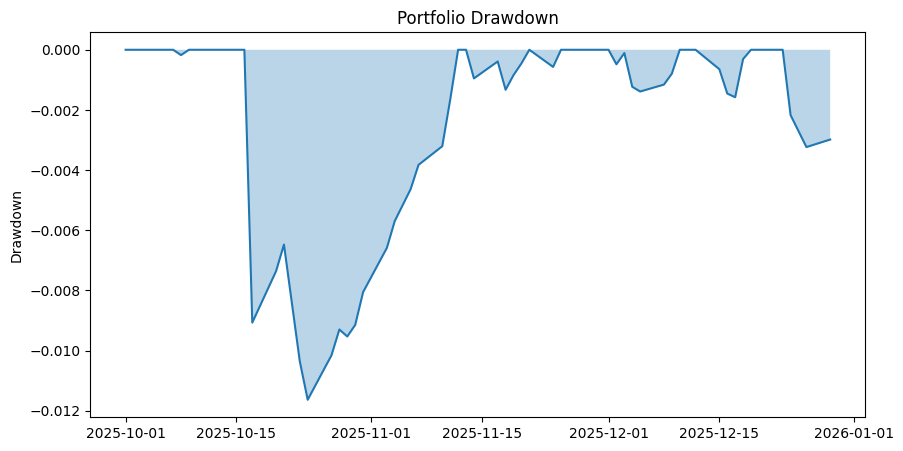

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.index, df["Drawdown"])
plt.fill_between(df.index, df["Drawdown"], 0, alpha=0.3)
plt.title("Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.show()